# Modelando o Tempo de Volta na Fórmula 1: Regressão Linear vs Random Forest

**Objetivo:** prever o tempo de volta de um carro de F1 durante uma corrida a partir do desgaste do pneu, do composto usado, da volta da corrida, das condições de pista e da equipe.

**Por que esse problema é interessante:** o tempo de volta resulta de efeitos que atuam ao mesmo tempo e de formas diferentes:

- **Combustível:** o carro começa pesado e fica mais leve a cada volta, o que deixa as voltas mais rápidas.
- **Desgaste do pneu:** o pneu perde aderência com o uso, o que deixa as voltas mais lentas.
- **Composto:** pneus macios são mais rápidos no início, mas desgastam mais rápido que os duros.

O efeito do desgaste **depende do composto**. Esse tipo de interação é exatamente o que diferencia um modelo linear de um modelo baseado em árvores.

**Pergunta central:** o Random Forest consegue aprender a curva de degradação de cada pneu melhor que a Regressão Linear? E se a gente ajudar a Regressão Linear com variáveis de interação?

**Dados:** voltas reais obtidas com a biblioteca [FastF1](https://docs.fastf1.dev/), que acessa os dados oficiais de cronometragem da F1.

**Tecnologias:** Python, FastF1, pandas, scikit-learn, matplotlib, seaborn

In [1]:
# No Google Colab, instale a FastF1 antes de rodar o restante
%pip install -q fastf1

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fastf1

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

# Corrida analisada: troque aqui para testar outras
ANO = 2024
CORRIDA = "Bahrain"

# Cores oficiais dos compostos (duro em cinza para aparecer no fundo branco)
CORES_COMPOSTO = {"SOFT": "#DA291C", "MEDIUM": "#FFD12E", "HARD": "#7F7F7F"}

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Coletando os dados

A FastF1 baixa os dados oficiais da sessão e guarda uma cópia local em cache. Assim, a partir da segunda execução, o carregamento é bem mais rápido.

Carrego as voltas da corrida e os dados de clima. Como o clima é medido em horários diferentes do início de cada volta, uso `merge_asof` para associar a cada volta a medição mais recente disponível naquele momento.

As colunas usadas são salvas em `dados/` (formato parquet). Se esse arquivo já existir, o notebook lê direto dele, sem acessar o servidor da F1. Isso permite rodar o projeto em ambientes onde a FastF1 é bloqueada, como o Google Colab.

In [3]:
ARQUIVO = f"dados/{CORRIDA.lower()}_{ANO}_voltas.parquet"
COLUNAS = ["Driver", "Team", "LapNumber", "LapTime", "LapStartTime", "Compound", "TyreLife",
           "TrackStatus", "IsAccurate", "PitInTime", "PitOutTime", "TrackTemp", "AirTemp"]

if os.path.exists(ARQUIVO):
    df = pd.read_parquet(ARQUIVO)
    print(f"Dados carregados de {ARQUIVO}")
else:
    os.makedirs("cache_fastf1", exist_ok=True)
    fastf1.Cache.enable_cache("cache_fastf1")

    try:
        sessao = fastf1.get_session(ANO, CORRIDA, "R")
        sessao.load(telemetry=False)
        laps = sessao.laps
    except Exception as erro:
        raise RuntimeError(
            "Não foi possível carregar as voltas da sessão pela FastF1. Provavelmente o servidor "
            "de cronometragem da F1 bloqueou o acesso (acontece em ambientes de nuvem, como o Colab). "
            f"Rode o notebook localmente ou coloque o arquivo {ARQUIVO} no projeto."
        ) from erro
    if laps is None or len(laps) == 0:
        raise RuntimeError(
            "A FastF1 não retornou nenhuma volta. Provavelmente o servidor de cronometragem da F1 "
            f"bloqueou o acesso. Rode o notebook localmente ou coloque o arquivo {ARQUIVO} no projeto."
        )

    # Voltas: removo as que não têm horário de início, necessário para cruzar com o clima
    voltas = pd.DataFrame(laps).dropna(subset=["LapStartTime"]).sort_values("LapStartTime")

    # Clima: registrado a cada minuto, aproximadamente
    clima = (
        sessao.weather_data[["Time", "AirTemp", "TrackTemp"]]
        .rename(columns={"Time": "HorarioClima"})
        .sort_values("HorarioClima")
    )

    # Para cada volta, pega a medição de clima mais recente antes do início da volta
    df = pd.merge_asof(voltas, clima, left_on="LapStartTime", right_on="HorarioClima",
                       direction="backward")

    # Salva só as colunas usadas, para rodar sem acesso ao servidor da F1
    df = df[COLUNAS]
    os.makedirs("dados", exist_ok=True)
    df.to_parquet(ARQUIVO, index=False)
    print(f"Dados baixados pela FastF1 e salvos em {ARQUIVO}")

print(f"Total de voltas registradas: {len(df)}")

Dados carregados de dados/bahrain_2024_voltas.parquet
Total de voltas registradas: 1129


Colunas usadas no projeto:

| Coluna | Significado |
|---|---|
| `LapTime` | Tempo da volta (**alvo**) |
| `LapNumber` | Número da volta na corrida. Funciona como indicador da quantidade de combustível |
| `TyreLife` | Quantas voltas o pneu já tinha completado |
| `Compound` | Composto do pneu: SOFT (macio), MEDIUM (médio) ou HARD (duro) |
| `Team` | Equipe do piloto |
| `TrackTemp` | Temperatura da pista (°C) |
| `AirTemp` | Temperatura do ar (°C) |
| `PitInTime`, `PitOutTime` | Preenchidos em voltas de entrada ou saída dos boxes |
| `TrackStatus` | Situação da pista. `"1"` significa bandeira verde |
| `IsAccurate` | Indica se a FastF1 considera a cronometragem da volta confiável |

In [4]:
df[["Driver", "Team", "LapNumber", "LapTime", "Compound", "TyreLife",
    "TrackStatus", "TrackTemp", "AirTemp"]].head(10)

,Driver,Team,LapNumber,LapTime,Compound,TyreLife,TrackStatus,TrackTemp,AirTemp
0,VER,Red Bull Racing,1.0,0 days 00:01:37.284000,SOFT,4.0,12,23.8,18.3
1,LEC,Ferrari,1.0,0 days 00:01:38.271000,SOFT,4.0,12,23.8,18.3
2,RUS,Mercedes,1.0,0 days 00:01:39.228000,SOFT,4.0,12,23.8,18.3
3,NOR,McLaren,1.0,0 days 00:01:42.168000,SOFT,4.0,12,23.8,18.3
4,HAM,Mercedes,1.0,0 days 00:01:43.122000,SOFT,4.0,12,23.8,18.3
5,PIA,McLaren,1.0,0 days 00:01:42.523000,SOFT,4.0,12,23.8,18.3
6,ALO,Aston Martin,1.0,0 days 00:01:41.679000,SOFT,4.0,12,23.8,18.3
7,SAR,Williams,1.0,0 days 00:01:45.921000,SOFT,1.0,12,23.8,18.3
8,SAI,Ferrari,1.0,0 days 00:01:40.620000,SOFT,4.0,12,23.8,18.3
9,ZHO,Kick Sauber,1.0,0 days 00:01:44.801000,SOFT,1.0,12,23.8,18.3


## 2. Limpeza dos dados

Dados reais de corrida têm muitas voltas que não representam o ritmo normal do carro. Se elas entrarem no treino, o modelo aprende ruído. Removo:

- **Primeira volta:** largada parada, com carros agrupados.
- **Voltas de box:** a entrada e a saída dos boxes somam vários segundos ao tempo.
- **Voltas fora de bandeira verde:** safety car e bandeira amarela obrigam os pilotos a desacelerar.
- **Voltas com cronometragem imprecisa.**
- **Pneus de chuva:** o foco é o comportamento em pista seca.
- **Voltas 7% mais lentas que a mais rápida:** mesmo critério usado na classificação da F1. Elimina voltas com erros, tráfego pesado ou problemas.

In [5]:
df["LapTimeSeg"] = df["LapTime"].dt.total_seconds()

def aplicar_filtro(dados, condicao, descricao):
    """Aplica um filtro e mostra quantas voltas restaram."""
    mantidas = dados[condicao(dados)]
    print(f"{descricao:<52} {len(dados):>5} -> {len(mantidas):>5}")
    return mantidas

limpo = df.copy()
limpo = aplicar_filtro(limpo, lambda d: d["LapTimeSeg"].notna(), "Remove voltas sem tempo registrado")
limpo = aplicar_filtro(limpo, lambda d: d["LapNumber"] > 1, "Remove a primeira volta")
limpo = aplicar_filtro(limpo, lambda d: d["PitInTime"].isna() & d["PitOutTime"].isna(), "Remove voltas de entrada e saída dos boxes")
limpo = aplicar_filtro(limpo, lambda d: d["TrackStatus"] == "1", "Mantém só voltas com bandeira verde")
limpo = aplicar_filtro(limpo, lambda d: d["IsAccurate"].eq(True), "Mantém só voltas com cronometragem precisa")
limpo = aplicar_filtro(limpo, lambda d: d["Compound"].isin(["SOFT", "MEDIUM", "HARD"]), "Mantém só pneus de pista seca")
limpo = aplicar_filtro(limpo, lambda d: d["LapTimeSeg"] <= 1.07 * d["LapTimeSeg"].min(), "Remove voltas 7% mais lentas que a mais rápida")
limpo = aplicar_filtro(limpo, lambda d: d[["TyreLife", "TrackTemp", "AirTemp"]].notna().all(axis=1), "Remove voltas com dados faltando")

print(f"\nVoltas usadas no projeto: {len(limpo)} ({len(limpo) / len(df):.0%} do total)")

Remove voltas sem tempo registrado                    1129 ->  1127
Remove a primeira volta                               1127 ->  1107
Remove voltas de entrada e saída dos boxes            1107 ->  1024
Mantém só voltas com bandeira verde                   1024 ->  1006
Mantém só voltas com cronometragem precisa            1006 ->  1006
Mantém só pneus de pista seca                         1006 ->  1006
Remove voltas 7% mais lentas que a mais rápida        1006 ->   974
Remove voltas com dados faltando                       974 ->   974

Voltas usadas no projeto: 974 (86% do total)


## 3. Análise exploratória

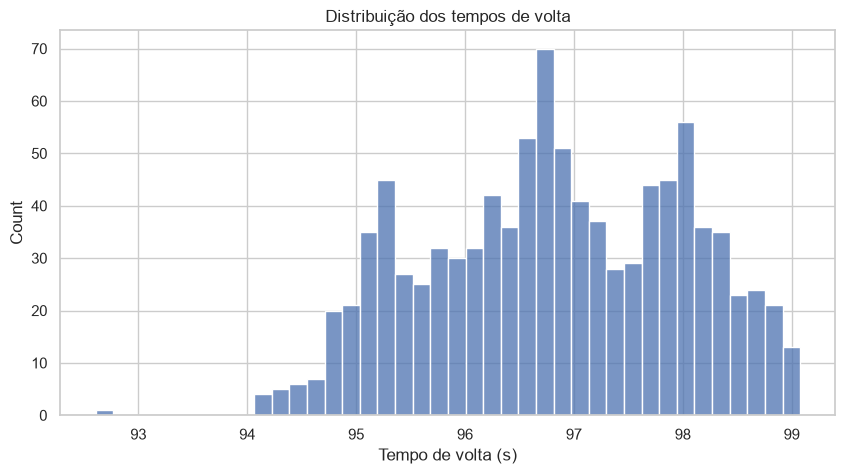

count    974.000
mean      96.819
std        1.171
min       92.608
25%       95.935
50%       96.802
75%       97.815
max       99.078
Name: LapTimeSeg, dtype: float64


In [6]:
fig, ax = plt.subplots()
sns.histplot(limpo["LapTimeSeg"], bins=40, ax=ax)
ax.set_title("Distribuição dos tempos de volta")
ax.set_xlabel("Tempo de volta (s)")
plt.show()

print(limpo["LapTimeSeg"].describe().round(3))

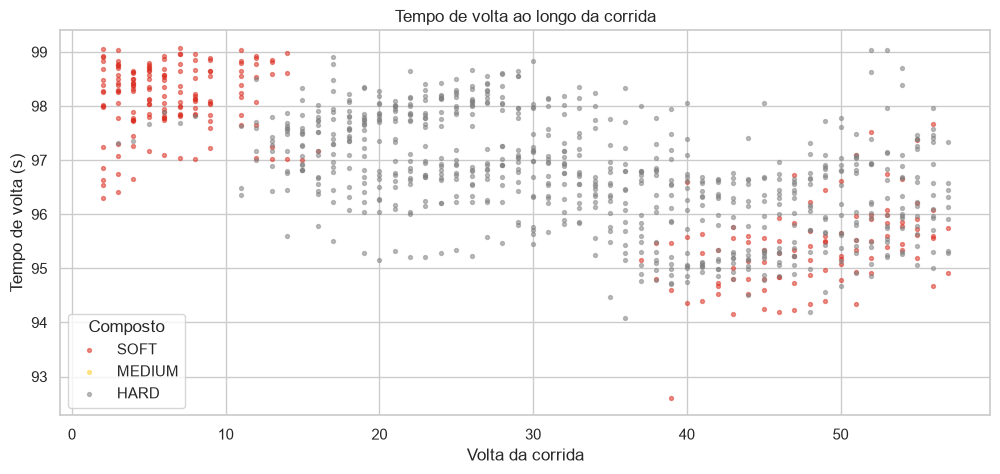

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
for composto, cor in CORES_COMPOSTO.items():
    dados = limpo[limpo["Compound"] == composto]
    ax.scatter(dados["LapNumber"], dados["LapTimeSeg"], s=8, alpha=0.5,
               color=cor, label=composto)
ax.set_title("Tempo de volta ao longo da corrida")
ax.set_xlabel("Volta da corrida")
ax.set_ylabel("Tempo de volta (s)")
ax.legend(title="Composto")
plt.show()

**O que observar:** ao longo da corrida, o tempo tende a cair porque o carro queima combustível e fica mais leve. Dentro de cada stint (período com o mesmo jogo de pneus), o tempo tende a subir por causa do desgaste. Os dois efeitos acontecem ao mesmo tempo, e o modelo precisa separá-los.

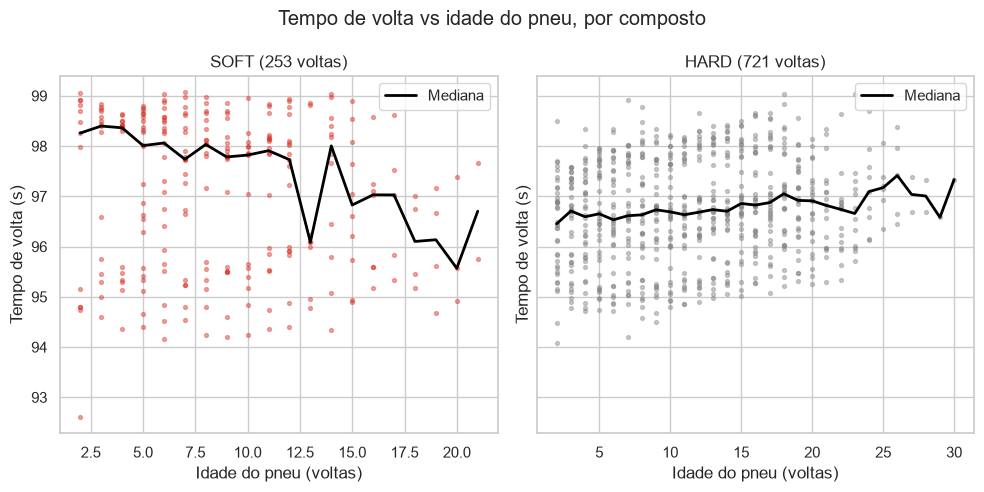

In [8]:
compostos_presentes = [c for c in CORES_COMPOSTO if c in limpo["Compound"].unique()]

fig, axes = plt.subplots(1, len(compostos_presentes), figsize=(5 * len(compostos_presentes), 5), sharey=True)
axes = np.atleast_1d(axes)

for ax, composto in zip(axes, compostos_presentes):
    dados = limpo[limpo["Compound"] == composto]
    ax.scatter(dados["TyreLife"], dados["LapTimeSeg"], s=8, alpha=0.4,
               color=CORES_COMPOSTO[composto])
    # Mediana do tempo para cada idade de pneu: mostra a tendência sem assumir uma reta
    mediana = dados.groupby("TyreLife")["LapTimeSeg"].median()
    ax.plot(mediana.index, mediana.values, color="black", linewidth=2, label="Mediana")
    ax.legend()
    ax.set_title(f"{composto} ({len(dados)} voltas)")
    ax.set_xlabel("Idade do pneu (voltas)")
    ax.set_ylabel("Tempo de volta (s)")

plt.suptitle("Tempo de volta vs idade do pneu, por composto")
plt.tight_layout()
plt.show()

A linha preta é a mediana do tempo de volta para cada idade de pneu. Ela mostra a tendência sem assumir que a relação é uma reta. Compare a inclinação entre os compostos: se ela muda, o efeito do desgaste depende do composto.

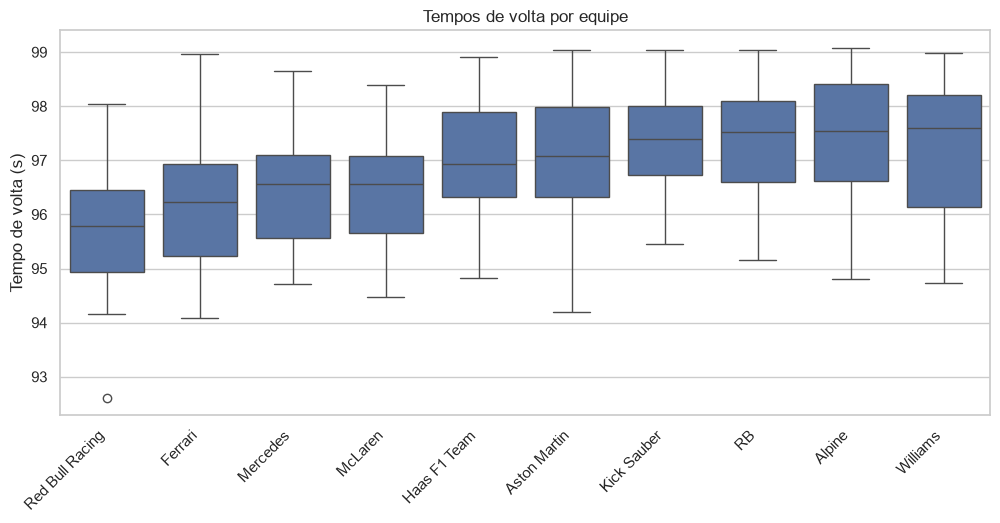

In [9]:
ordem = limpo.groupby("Team")["LapTimeSeg"].median().sort_values().index

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=limpo, x="Team", y="LapTimeSeg", order=ordem, ax=ax)
ax.set_title("Tempos de volta por equipe")
ax.set_xlabel("")
ax.set_ylabel("Tempo de volta (s)")
plt.xticks(rotation=45, ha="right")
plt.show()

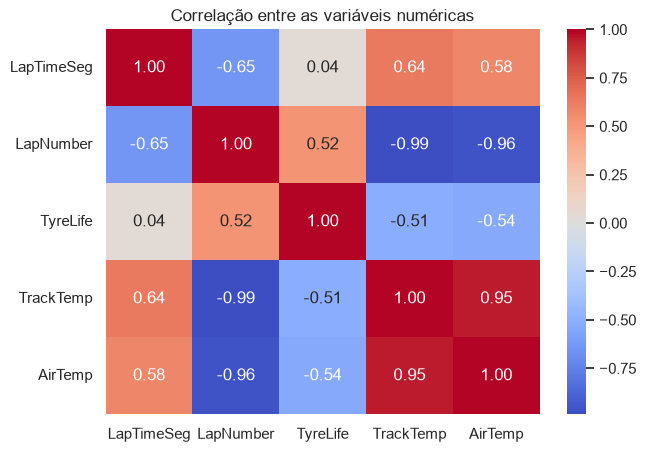

In [10]:
colunas_numericas = ["LapTimeSeg", "LapNumber", "TyreLife", "TrackTemp", "AirTemp"]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(limpo[colunas_numericas].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlação entre as variáveis numéricas")
plt.show()

**Atenção à correlação entre `LapNumber` e `TrackTemp`:** em uma única corrida, a temperatura da pista muda com o horário, que avança junto com as voltas. Quando duas variáveis andam juntas, o modelo tem dificuldade em separar o efeito de cada uma. Isso afeta principalmente a interpretação dos coeficientes da Regressão Linear.

## 4. Preparando as variáveis

Os modelos só trabalham com números, então as variáveis categóricas (`Compound` e `Team`) são transformadas com **one-hot encoding**: cada categoria vira uma coluna com 0 ou 1.

Uso `drop_first=True` para remover uma categoria de cada variável. Ela vira a **referência**, e os coeficientes das outras são interpretados em relação a ela. Sem isso, as colunas seriam redundantes (a soma delas daria sempre 1), o que atrapalha a Regressão Linear.

In [11]:
colunas_num = ["LapNumber", "TyreLife", "TrackTemp", "AirTemp"]
colunas_cat = ["Compound", "Team"]

X = pd.get_dummies(limpo[colunas_num + colunas_cat], columns=colunas_cat,
                   drop_first=True, dtype=int)
y = limpo["LapTimeSeg"]

colunas_composto = [c for c in X.columns if c.startswith("Compound_")]
referencia_composto = sorted(limpo["Compound"].unique())[0]

print(f"Variáveis: {X.shape[1]}")
print(f"Composto de referência: {referencia_composto}")
print(f"Colunas de composto: {colunas_composto}")

Variáveis: 14
Composto de referência: HARD
Colunas de composto: ['Compound_SOFT']


## 5. Separação entre treino e teste

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Treino: {len(X_train)} voltas")
print(f"Teste:  {len(X_test)} voltas")

Treino: 779 voltas
Teste:  195 voltas


**Limitação importante:** a divisão é aleatória por volta. Voltas consecutivas do mesmo piloto são muito parecidas, então o conjunto de teste tem voltas "vizinhas" de voltas que estão no treino. Isso deixa as métricas um pouco otimistas. Uma avaliação mais rigorosa separaria por piloto ou por corrida (ver próximos passos).

## 6. Métricas e baseline

Uso três métricas: **MAE**, **RMSE** e **R²**. Aqui, MAE e RMSE estão em **segundos**, o que facilita a interpretação: um MAE de 0,5 significa que o modelo erra, em média, meio segundo por volta.

In [13]:
def avaliar(nome, modelo, X, y):
    """Calcula MAE, RMSE e R² de um modelo já treinado."""
    pred = modelo.predict(X)
    return {
        "Modelo": nome,
        "MAE (s)": mean_absolute_error(y, pred),
        "RMSE (s)": np.sqrt(mean_squared_error(y, pred)),
        "R²": r2_score(y, pred),
    }

resultados = []

baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)
resultados.append(avaliar("Baseline (média)", baseline, X_test, y_test))
pd.DataFrame(resultados).round(3)

,Modelo,MAE (s),RMSE (s),R²
0,Baseline (média),0.977,1.173,-0.012


## 7. Regressão Linear

A Regressão Linear assume que cada variável tem um efeito **fixo e aditivo** no tempo de volta. Por exemplo: cada volta de uso do pneu soma sempre os mesmos X segundos, **seja qual for o composto**.

Esse pressuposto é o ponto fraco do modelo neste problema, como a análise exploratória sugeriu.

In [14]:
modelo_lr = make_pipeline(StandardScaler(), LinearRegression())
modelo_lr.fit(X_train, y_train)

resultados.append(avaliar("Regressão Linear", modelo_lr, X_test, y_test))
pd.DataFrame(resultados).round(3)

,Modelo,MAE (s),RMSE (s),R²
0,Baseline (média),0.977,1.173,-0.012
1,Regressão Linear,0.259,0.370,0.900


In [15]:
# Coeficientes sem padronização, para interpretar em segundos por unidade
lr_simples = LinearRegression().fit(X_train, y_train)
coefs = pd.Series(lr_simples.coef_, index=X.columns)

print("Efeito estimado de cada variável numérica no tempo de volta:")
for col in colunas_num:
    print(f"  {col:<10} {coefs[col]:+.4f} s por unidade")

print(f"\nEfeito do composto (em relação ao {referencia_composto}):")
for col in colunas_composto:
    print(f"  {col:<16} {coefs[col]:+.3f} s")

Efeito estimado de cada variável numérica no tempo de volta:
  LapNumber  -0.0718 s por unidade
  TyreLife   +0.1103 s por unidade
  TrackTemp  +0.2975 s por unidade
  AirTemp    -1.0724 s por unidade

Efeito do composto (em relação ao HARD):
  Compound_SOFT    +0.023 s


**Como ler:** o coeficiente de `LapNumber` estima o ganho de tempo por volta devido à queima de combustível (deve ser negativo). O de `TyreLife` estima a perda de tempo por volta de uso do pneu (deve ser positivo).

Se algum sinal parecer contraintuitivo, lembre da correlação entre `LapNumber` e `TrackTemp`: parte do efeito de uma pode estar sendo atribuída à outra.

**Os coeficientes de `TrackTemp` e `AirTemp` não devem ser interpretados.** O de `AirTemp` (≈ −1,07 s por °C) é implausível: em uma única corrida, as temperaturas mudam junto com `LapNumber`, e essa colinearidade faz o modelo dividir o efeito entre as variáveis de forma arbitrária. Elas ajudam na previsão, mas o valor isolado de cada coeficiente não tem significado físico.

Aqui treinei uma versão sem padronização só para interpretar em segundos. A versão com `StandardScaler` dá exatamente as mesmas previsões, só muda a escala dos coeficientes.

## 8. Regressão Linear com interação

E se a gente **ensinar** à Regressão Linear que o desgaste depende do composto? Basta criar novas variáveis multiplicando `TyreLife` pelas colunas de composto:

$$\text{TyreLife} \times \text{Compound\_SOFT}$$

Essa variável vale a idade do pneu quando o composto é macio, e 0 caso contrário. Assim, o modelo pode estimar uma inclinação de desgaste **diferente para cada composto**.

**Nesta corrida, após a limpeza, só restaram dois compostos: SOFT e HARD.** Como HARD é a referência, a interação acrescenta uma única variável (`TyreLife_x_Compound_SOFT`).

Uso um `FunctionTransformer` dentro do pipeline para criar essas colunas automaticamente, tanto no treino quanto na previsão.

In [16]:
def adicionar_interacoes(X):
    """Cria colunas de interação entre a idade do pneu e cada composto."""
    X = X.copy()
    for col in [c for c in X.columns if c.startswith("Compound_")]:
        X[f"TyreLife_x_{col}"] = X["TyreLife"] * X[col]
    return X

modelo_lr_int = make_pipeline(
    FunctionTransformer(adicionar_interacoes),
    StandardScaler(),
    LinearRegression(),
)
modelo_lr_int.fit(X_train, y_train)

resultados.append(avaliar("Regressão Linear + interação", modelo_lr_int, X_test, y_test))
pd.DataFrame(resultados).round(3)

,Modelo,MAE (s),RMSE (s),R²
0,Baseline (média),0.977,1.173,-0.012
1,Regressão Linear,0.259,0.370,0.900
2,Regressão Linear + interação,0.259,0.369,0.900


## 9. Random Forest Regressor

O Random Forest não precisa que as interações sejam criadas manualmente. Como cada árvore divide os dados em regiões (por exemplo, `Compound_SOFT = 1` e depois `TyreLife > 15`), ele pode aprender uma curva de desgaste diferente para cada composto por conta própria.

Com 974 voltas após a limpeza, o treino é rápido.

In [17]:
modelo_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
modelo_rf.fit(X_train, y_train)

resultados.append(avaliar("Random Forest", modelo_rf, X_test, y_test))
pd.DataFrame(resultados).round(3)

,Modelo,MAE (s),RMSE (s),R²
0,Baseline (média),0.977,1.173,-0.012
1,Regressão Linear,0.259,0.370,0.900
2,Regressão Linear + interação,0.259,0.369,0.900
3,Random Forest,0.286,0.394,0.886


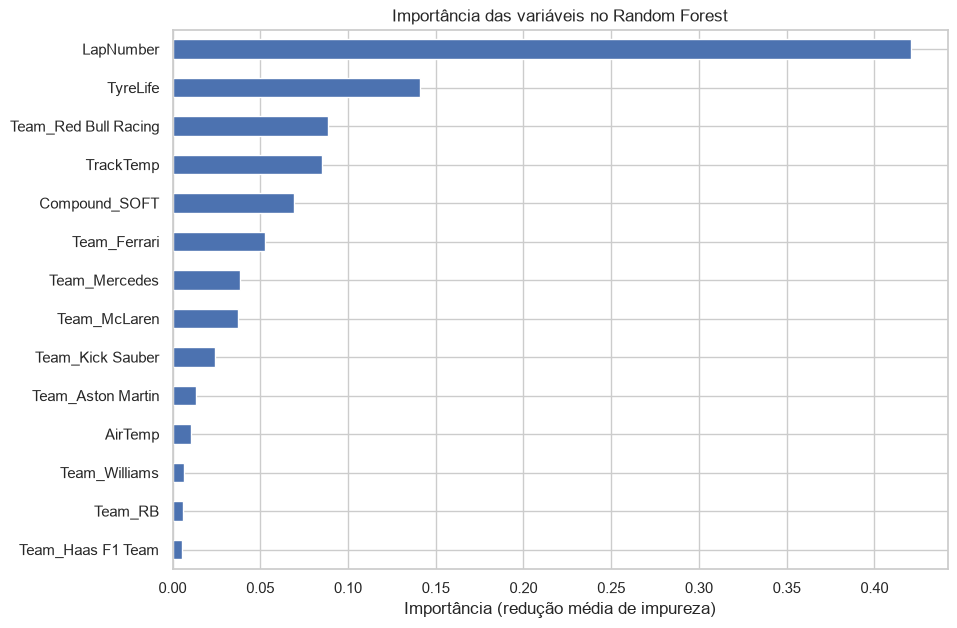

In [18]:
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
importancias.plot(kind="barh", ax=ax)
ax.set_title("Importância das variáveis no Random Forest")
ax.set_xlabel("Importância (redução média de impureza)")
plt.show()

**Cuidado ao comparar importâncias:** a equipe está dividida em várias colunas de 0 e 1, então a importância total da equipe fica espalhada entre elas. Para comparar com variáveis contínuas como `TyreLife`, o justo seria somar as importâncias das colunas de equipe.

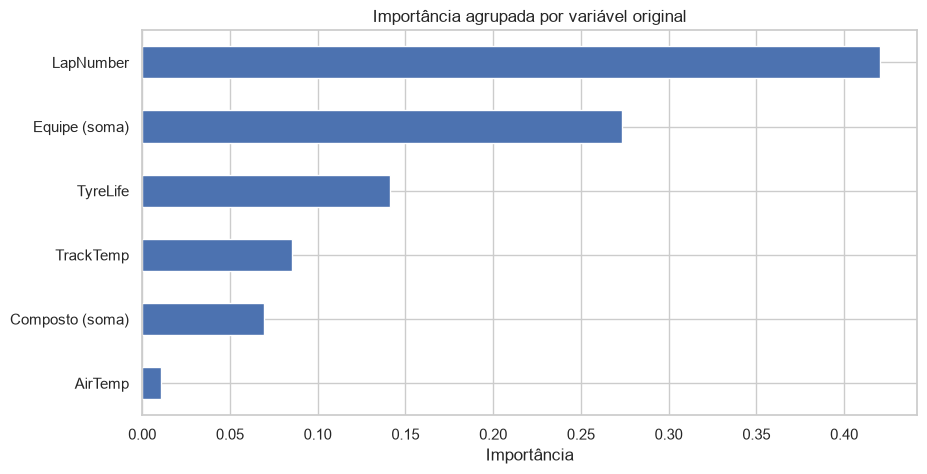

In [19]:
importancia_agrupada = pd.Series({
    "Equipe (soma)": importancias[[c for c in X.columns if c.startswith("Team_")]].sum(),
    "Composto (soma)": importancias[colunas_composto].sum(),
    **{col: importancias[col] for col in colunas_num},
}).sort_values()

fig, ax = plt.subplots()
importancia_agrupada.plot(kind="barh", ax=ax)
ax.set_title("Importância agrupada por variável original")
ax.set_xlabel("Importância")
plt.show()

### Verificando overfitting

In [20]:
modelos = {
    "Regressão Linear": modelo_lr,
    "Regressão Linear + interação": modelo_lr_int,
    "Random Forest": modelo_rf,
}

for nome, modelo in modelos.items():
    r2_treino = r2_score(y_train, modelo.predict(X_train))
    r2_teste = r2_score(y_test, modelo.predict(X_test))
    print(f"{nome:<30} | R² treino: {r2_treino:.3f} | R² teste: {r2_teste:.3f} | diferença: {r2_treino - r2_teste:.3f}")

Regressão Linear               | R² treino: 0.879 | R² teste: 0.900 | diferença: -0.020
Regressão Linear + interação   | R² treino: 0.879 | R² teste: 0.900 | diferença: -0.020
Random Forest                  | R² treino: 0.980 | R² teste: 0.886 | diferença: 0.094


## 10. Validação cruzada

Com 974 voltas após a limpeza, uma única divisão treino/teste pode variar bastante. A validação cruzada com 5 folds mostra se os resultados são estáveis.

In [21]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
metricas_cv = {"mae": "neg_mean_absolute_error", "r2": "r2"}

linhas_cv = []
for nome, modelo in modelos.items():
    cv = cross_validate(modelo, X_train, y_train, cv=kfold, scoring=metricas_cv, n_jobs=1)
    linhas_cv.append({
        "Modelo": nome,
        "MAE médio (s)": -cv["test_mae"].mean(),
        "MAE desvio (s)": cv["test_mae"].std(),
        "R² médio": cv["test_r2"].mean(),
        "R² desvio": cv["test_r2"].std(),
    })

pd.DataFrame(linhas_cv).round(3)

,Modelo,MAE médio (s),MAE desvio (s),R² médio,R² desvio
0,Regressão Linear,0.306,0.017,0.874,0.008
1,Regressão Linear + interação,0.306,0.017,0.874,0.008
2,Random Forest,0.304,0.002,0.868,0.003


## 11. Comparação dos modelos

In [22]:
tabela = pd.DataFrame(resultados).set_index("Modelo").round(3)
tabela

,MAE (s),RMSE (s),R²
Modelo,,,
Baseline (média),0.977,1.173,-0.012
Regressão Linear,0.259,0.370,0.900
Regressão Linear + interação,0.259,0.369,0.900
Random Forest,0.286,0.394,0.886


In [23]:
melhor = tabela.drop(index="Baseline (média)")["MAE (s)"].idxmin()
mae_lr = tabela.loc["Regressão Linear", "MAE (s)"]
mae_melhor = tabela.loc[melhor, "MAE (s)"]

print(f"Melhor modelo no teste: {melhor} (MAE de {mae_melhor:.3f} s por volta)")
if melhor != "Regressão Linear":
    print(f"Redução do MAE em relação à Regressão Linear simples: {(mae_lr - mae_melhor) / mae_lr:.1%}")

Melhor modelo no teste: Regressão Linear (MAE de 0.259 s por volta)


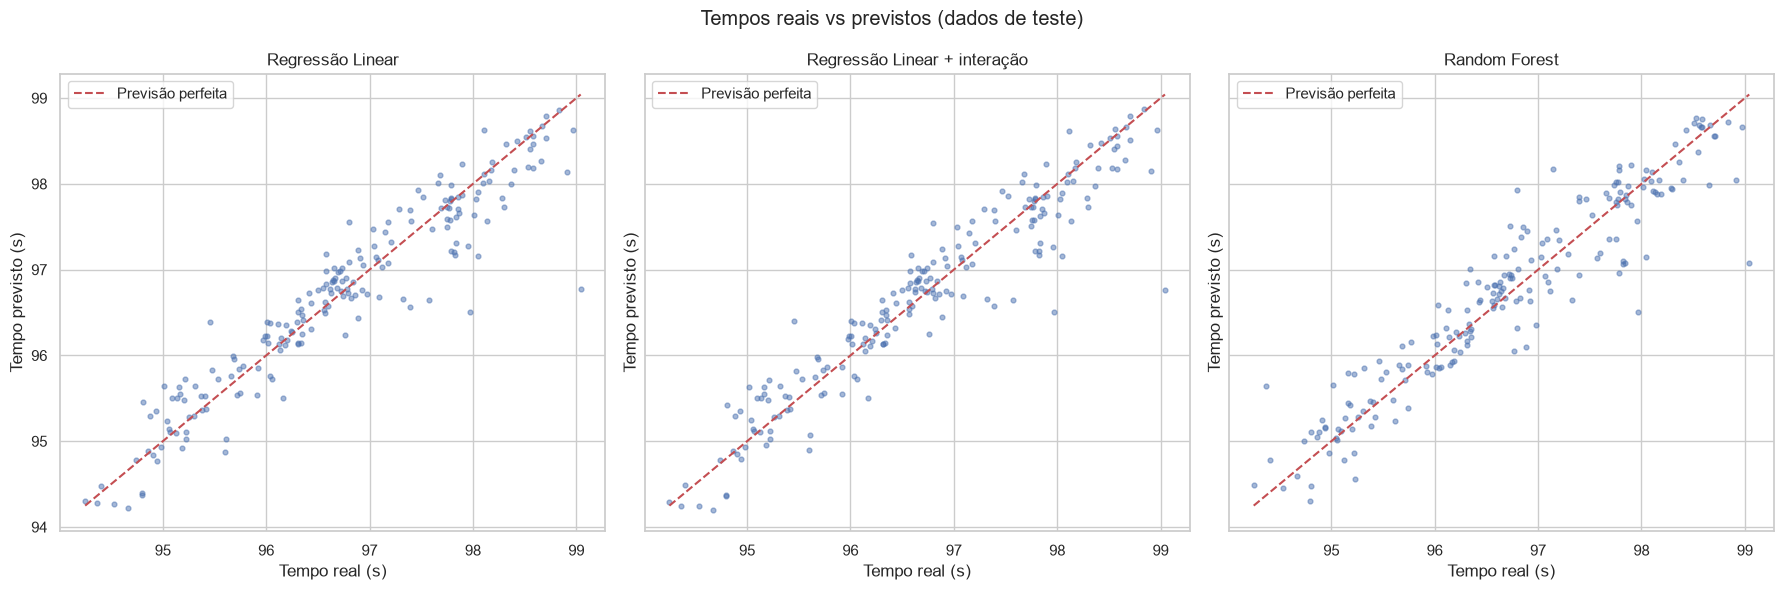

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

for ax, (nome, modelo) in zip(axes, modelos.items()):
    pred = modelo.predict(X_test)
    ax.scatter(y_test, pred, alpha=0.5, s=12)
    limites = [y_test.min(), y_test.max()]
    ax.plot(limites, limites, "r--", label="Previsão perfeita")
    ax.set_title(nome)
    ax.set_xlabel("Tempo real (s)")
    ax.set_ylabel("Tempo previsto (s)")
    ax.legend()

plt.suptitle("Tempos reais vs previstos (dados de teste)")
plt.tight_layout()
plt.show()

## 12. A curva de degradação aprendida por cada modelo

Esta é a análise mais reveladora do projeto. Para cada composto, simulo o que cada modelo prevê conforme o pneu envelhece:

1. Pego todas as voltas do conjunto de teste.
2. Fixo o composto e a idade do pneu em um valor.
3. Calculo a média das previsões.
4. Repito para cada idade de pneu, de 1 até a maior idade observada para aquele composto.

O resultado mostra **como cada modelo acha que o pneu degrada**, mantendo as outras variáveis como estavam.

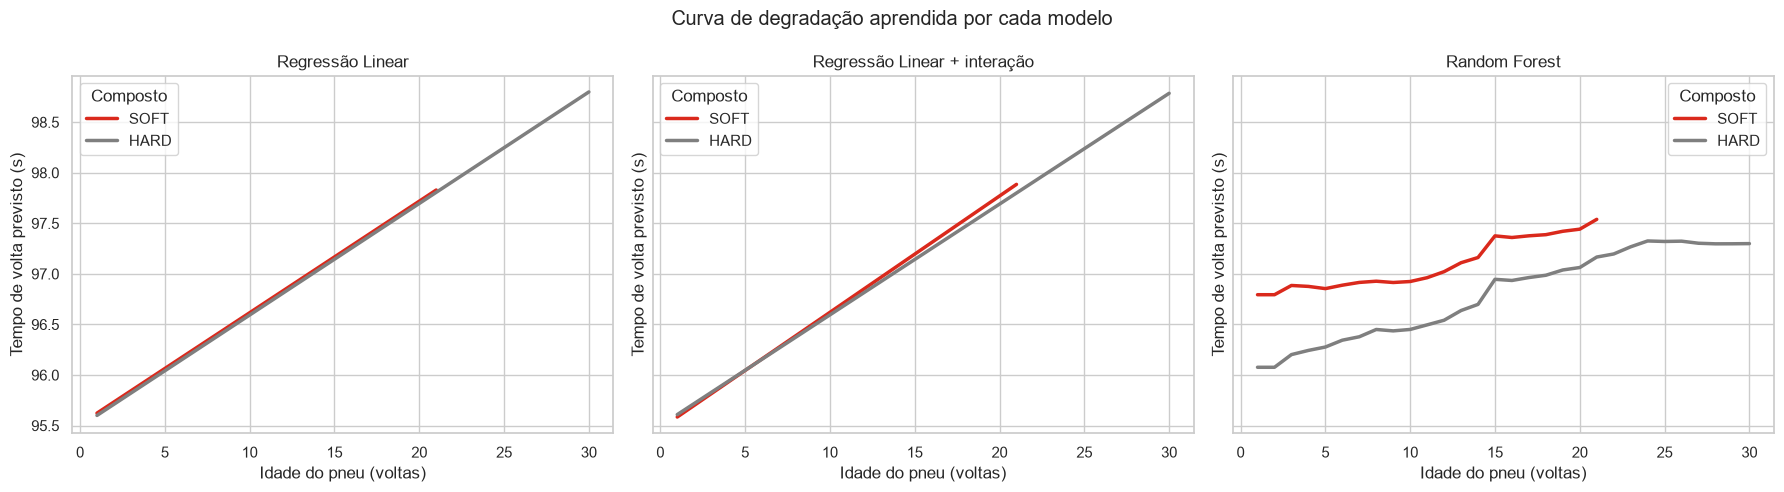

In [25]:
def curva_degradacao(modelo, composto):
    """Previsão média do tempo de volta para cada idade de pneu de um composto."""
    vida_max = int(limpo.loc[limpo["Compound"] == composto, "TyreLife"].max())
    idades = np.arange(1, vida_max + 1)
    medias = []
    for idade in idades:
        X_sim = X_test.copy()
        X_sim["TyreLife"] = idade
        X_sim[colunas_composto] = 0
        if f"Compound_{composto}" in X_sim.columns:
            X_sim[f"Compound_{composto}"] = 1
        medias.append(modelo.predict(X_sim).mean())
    return idades, np.array(medias)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (nome, modelo) in zip(axes, modelos.items()):
    for composto in compostos_presentes:
        idades, tempos = curva_degradacao(modelo, composto)
        ax.plot(idades, tempos, color=CORES_COMPOSTO[composto], linewidth=2.5, label=composto)
    ax.set_title(nome)
    ax.set_xlabel("Idade do pneu (voltas)")
    ax.set_ylabel("Tempo de volta previsto (s)")
    ax.legend(title="Composto")

plt.suptitle("Curva de degradação aprendida por cada modelo")
plt.tight_layout()
plt.show()

**Como interpretar:**

- **Regressão Linear:** as retas são **paralelas**. O modelo só consegue deslocar o nível de cada composto, com a mesma taxa de desgaste para todos.
- **Regressão Linear + interação:** as retas podem ter **inclinações diferentes**, mas continuam sendo retas. Como só restaram SOFT e HARD após a limpeza, a interação acrescenta uma única variável, que permite uma inclinação diferente para o SOFT.
- **Random Forest:** as curvas podem ter **qualquer formato**, inclusive acelerar o desgaste no fim do stint. Elas aparecem em "degraus" porque cada árvore divide os dados em faixas.

**Cuidado:** o Random Forest não extrapola. Fora da faixa de idades vista no treino, ele repete o último valor conhecido. Por isso as curvas vão só até a maior idade observada de cada composto.

## 13. Conclusões

| Modelo | MAE teste (s) | RMSE teste (s) | R² teste | MAE CV (s) | R² treino |
|---|---|---|---|---|---|
| Baseline (média) | 0,977 | 1,173 | −0,012 | — | — |
| Regressão Linear | 0,259 | 0,370 | 0,900 | 0,306 ± 0,017 | 0,879 |
| Regressão Linear + interação | 0,259 | 0,369 | 0,900 | 0,306 ± 0,017 | 0,879 |
| Random Forest | 0,286 | 0,394 | 0,886 | 0,304 ± 0,002 | 0,980 |

- **Todos os modelos superam com folga o baseline.** O MAE no teste cai de 0,98 s (prever sempre a média) para cerca de 0,26 s. Como a divisão aleatória por volta deixa o teste otimista, o MAE da validação cruzada (≈ 0,31 s) é a estimativa mais confiável do erro.
- **A interação não trouxe ganho.** A Regressão Linear com e sem interação tiveram resultados praticamente idênticos (só o RMSE difere, na terceira casa decimal). Após a limpeza, só restaram SOFT e HARD, e os dados desta corrida não mostram uma diferença de desgaste entre os dois compostos que o modelo aditivo não capte.
- **O Random Forest não superou a Regressão Linear.** Foi pior no teste (MAE de 0,286 s contra 0,259 s), empatou na validação cruzada (0,304 s contra 0,306 s) e mostrou overfitting: R² de 0,980 no treino contra 0,886 no teste.
- **Os efeitos principais têm o sinal esperado.** Cada volta de uso do pneu soma ≈ +0,11 s (`TyreLife`), e cada volta de corrida tira ≈ −0,07 s (`LapNumber`), coerente com a queima de combustível. Os coeficientes de temperatura não devem ser interpretados, por causa da colinearidade com `LapNumber`.
- **Resposta à pergunta central:** nesta corrida, o Random Forest não aprendeu a curva de degradação melhor que a Regressão Linear, e as variáveis de interação não foram necessárias. Com uma única corrida e só dois compostos, isso não permite generalizar para outras corridas.

## 14. Limitações

- Uma única corrida: o modelo aprende as condições específicas desse circuito e desse dia.
- A divisão aleatória por volta deixa as métricas otimistas, porque voltas vizinhas do mesmo piloto são muito parecidas.
- Variáveis importantes ficaram de fora: tráfego, uso de DRS, modo de motor, gestão de pneus pelo piloto e diferenças entre pilotos da mesma equipe.
- `LapNumber` é só uma aproximação da quantidade de combustível.

## 15. Próximos passos

- Validação com `GroupKFold` por piloto, para testar o modelo em pilotos que ele não viu no treino
- Combinar várias corridas e incluir o circuito como variável
- Usar a telemetria da FastF1 (velocidade, acelerador, freio) para criar novas variáveis
- Testar gradient boosting (XGBoost, LightGBM)